In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
clean_df = pd.read_csv("../data/processed/clean_mandi_prices.csv")
clean_df['Price Date'] = pd.to_datetime(clean_df['Price Date'], format='%Y-%m-%d')
clean_df['Year'] = clean_df['Price Date'].dt.year
clean_df['Month'] = clean_df['Price Date'].dt.month

monthly_df = pd.read_csv("../data/processed/monthly_crop_prices.csv")
crop_summary = pd.read_csv("../data/processed/crop_summary.csv")

print(clean_df.shape)
print(monthly_df.shape)
print(monthly_df.head())

(188080, 12)
(67, 4)
  Commodity  Year  Month  Avg_Modal_Price
0     Onion  2023      6      1119.212229
1     Onion  2023      7      1404.686554
2     Onion  2023      8      1691.915848
3     Onion  2023      9      1921.675517
4     Onion  2023     10      2189.736582


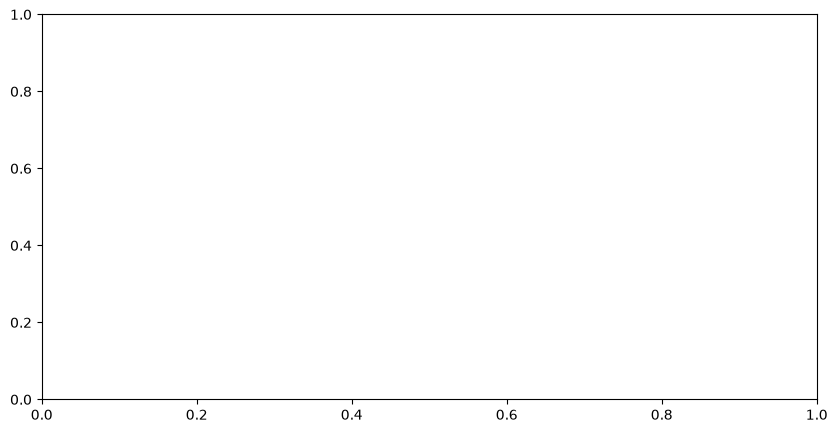

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))

In [3]:
print(monthly_df.dtypes)
print(monthly_df['Commodity'].unique())
print(monthly_df[monthly_df['Commodity'] == 'Onion'])

Commodity              str
Year                 int64
Month                int64
Avg_Modal_Price    float64
dtype: object
<StringArray>
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']
Length: 5, dtype: str
   Commodity  Year  Month  Avg_Modal_Price
0      Onion  2023      6      1119.212229
1      Onion  2023      7      1404.686554
2      Onion  2023      8      1691.915848
3      Onion  2023      9      1921.675517
4      Onion  2023     10      2189.736582
5      Onion  2023     11      3543.975133
6      Onion  2023     12      2737.284713
7      Onion  2024      1      1865.163121
8      Onion  2024      2      1559.834785
9      Onion  2024      3      1780.058879
10     Onion  2024      4      1690.977011
11     Onion  2024      5      1601.851347
12     Onion  2024      6      1515.201229
13     Onion  2024      7      2791.843037
14     Onion  2024      8      2934.244802
15     Onion  2024      9      3534.649784
16     Onion  2024     10      3848.854890
17     Onion  2024   

In [4]:
monthly_df['Date'] = pd.to_datetime(
    monthly_df['Year'].astype(str) + '-' + 
    monthly_df['Month'].astype(str) + '-01'
)

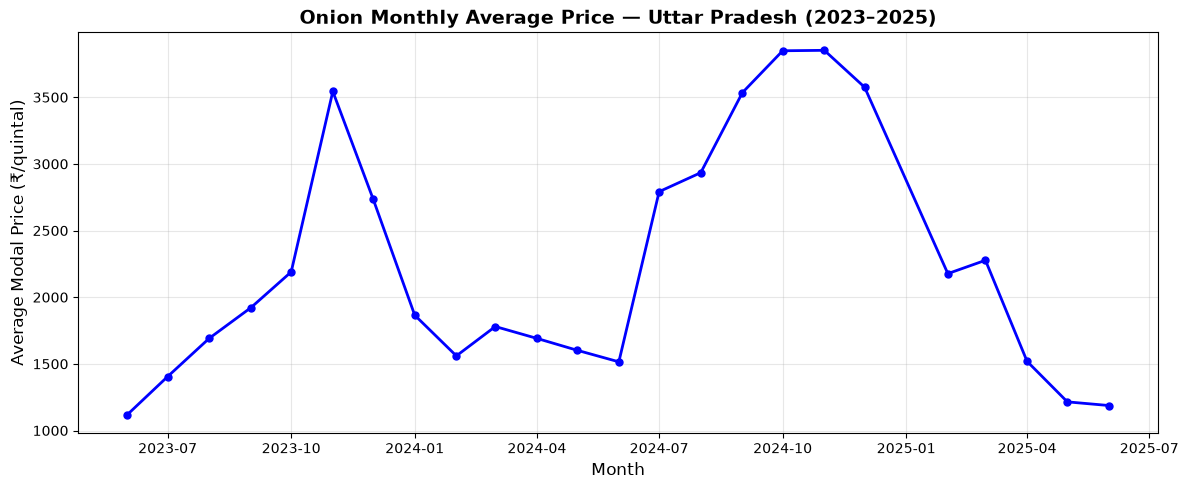

In [5]:
onion_df = monthly_df[monthly_df['Commodity'] == 'Onion'].sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(onion_df['Date'], onion_df['Avg_Modal_Price'],
        color='blue', linewidth=2, marker='o', markersize=5)

ax.set_title('Onion Monthly Average Price — Uttar Pradesh (2023–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

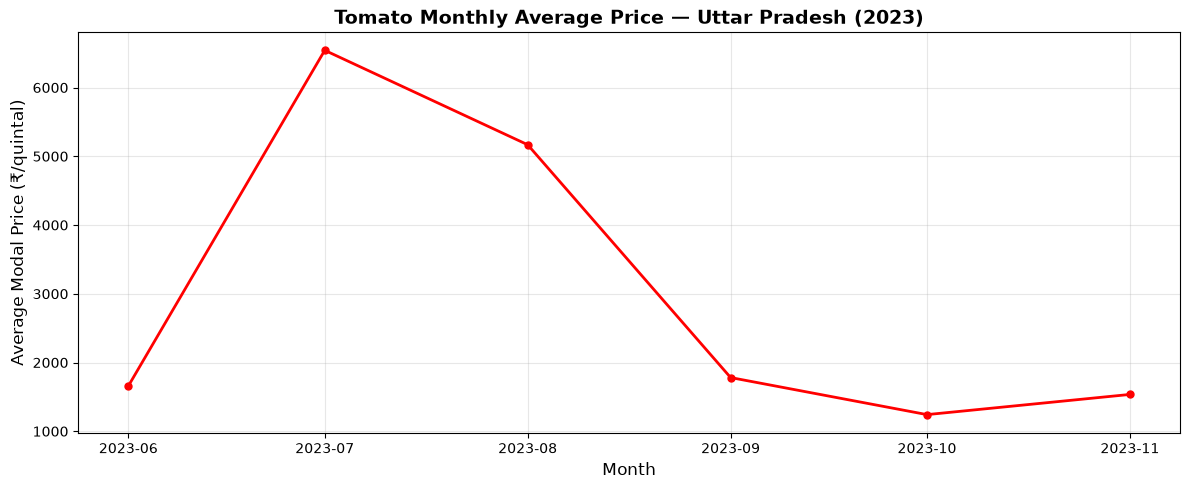

In [6]:
tomato_df = monthly_df[monthly_df['Commodity'] == 'Tomato'].sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(tomato_df['Date'], tomato_df['Avg_Modal_Price'],
        color='red', linewidth=2, marker='o', markersize=5)

ax.set_title('Tomato Monthly Average Price — Uttar Pradesh (2023)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

clean_df = pd.read_csv("../data/processed/clean_mandi_prices.csv")
clean_df['Price Date'] = pd.to_datetime(clean_df['Price Date'], format='%Y-%m-%d')
clean_df['Year'] = clean_df['Price Date'].dt.year
clean_df['Month'] = clean_df['Price Date'].dt.month

monthly_df = pd.read_csv("../data/processed/monthly_crop_prices.csv")
crop_summary = pd.read_csv("../data/processed/crop_summary.csv")

# Recreate the Date column
monthly_df['Date'] = pd.to_datetime(
    monthly_df['Year'].astype(str) + '-' +
    monthly_df['Month'].astype(str) + '-01'
)

print(monthly_df.columns.tolist())
print(monthly_df.shape)

['Commodity', 'Year', 'Month', 'Avg_Modal_Price', 'Date']
(67, 5)


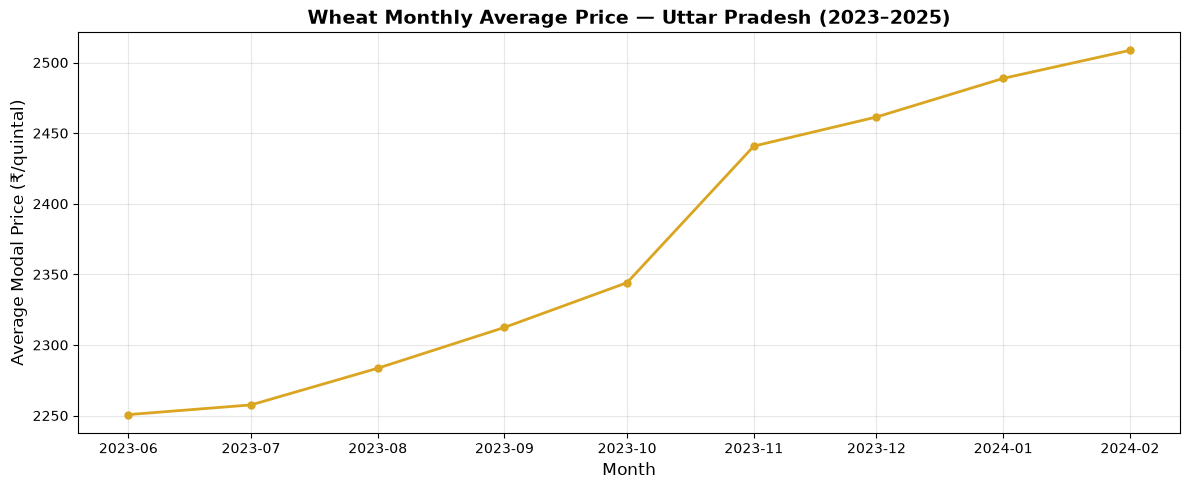

In [5]:
wheat_df = monthly_df[monthly_df['Commodity'] == 'Wheat'].sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(wheat_df['Date'], wheat_df['Avg_Modal_Price'],
        color='goldenrod', linewidth=2, marker='o', markersize=5)

ax.set_title('Wheat Monthly Average Price — Uttar Pradesh (2023–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

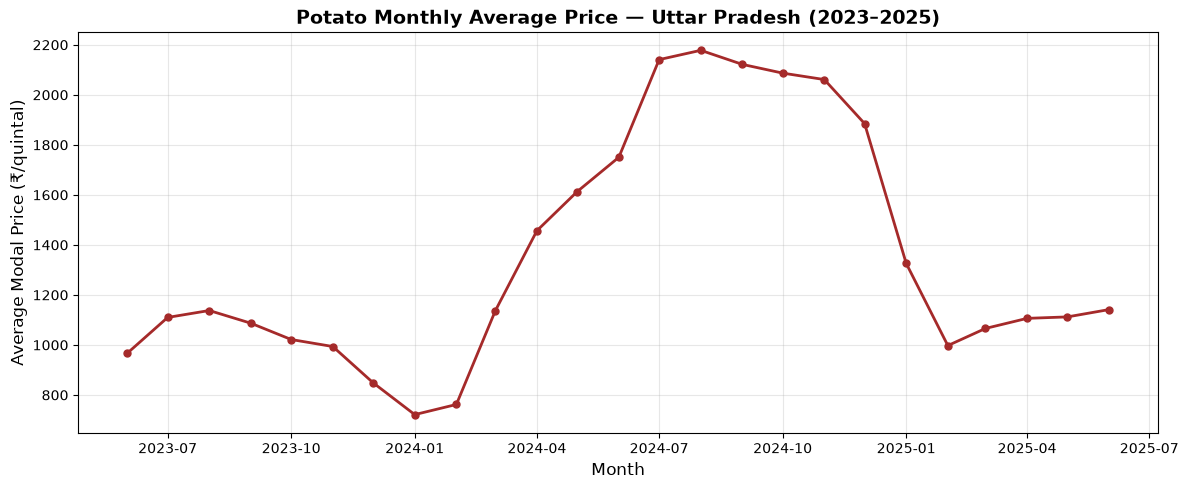

In [6]:
potato_df = monthly_df[monthly_df['Commodity'] == 'Potato'].sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(potato_df['Date'], potato_df['Avg_Modal_Price'],
        color='brown', linewidth=2, marker='o', markersize=5)

ax.set_title('Potato Monthly Average Price — Uttar Pradesh (2023–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

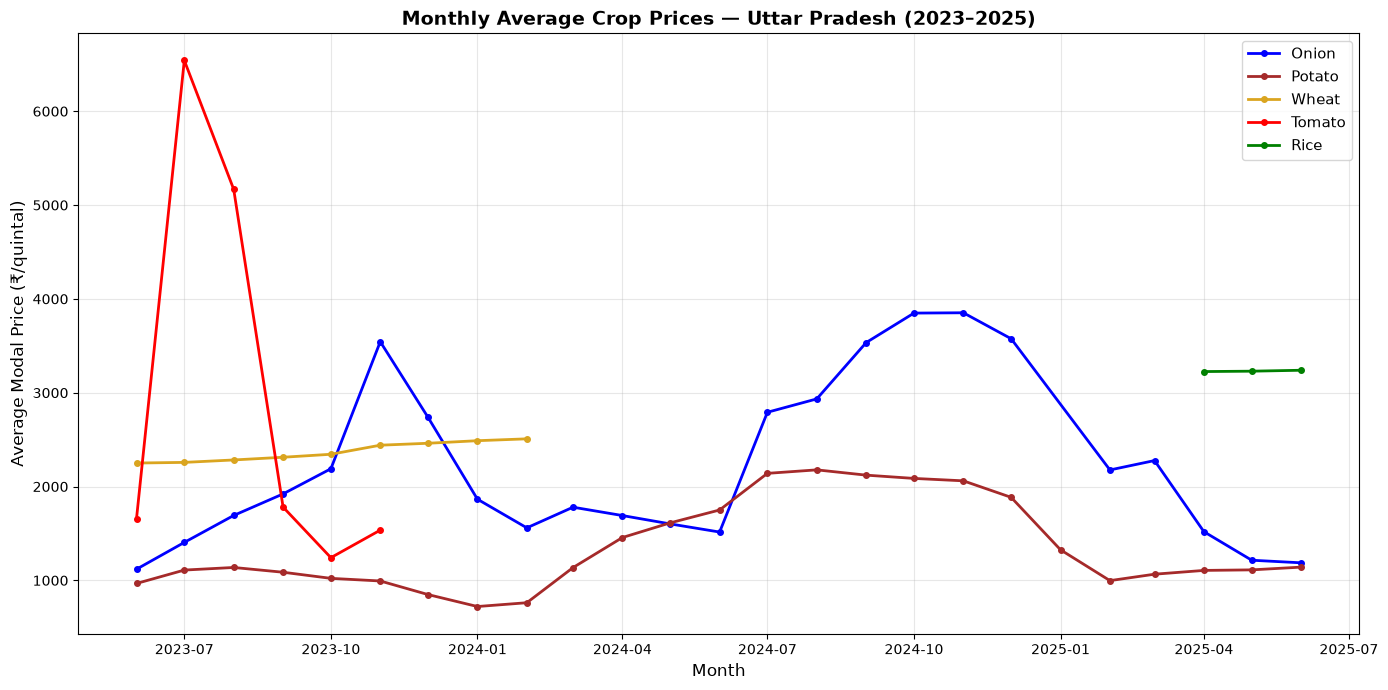

In [7]:
crops = ['Onion', 'Potato', 'Wheat', 'Tomato', 'Rice']
colors = ['blue', 'brown', 'goldenrod', 'red', 'green']

fig, ax = plt.subplots(figsize=(14, 7))

for crop, color in zip(crops, colors):
    crop_data = monthly_df[monthly_df['Commodity'] == crop].sort_values('Date')
    ax.plot(crop_data['Date'], crop_data['Avg_Modal_Price'],
            label=crop, color=color, linewidth=2, marker='o', markersize=4)

ax.set_title('Monthly Average Crop Prices — Uttar Pradesh (2023–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

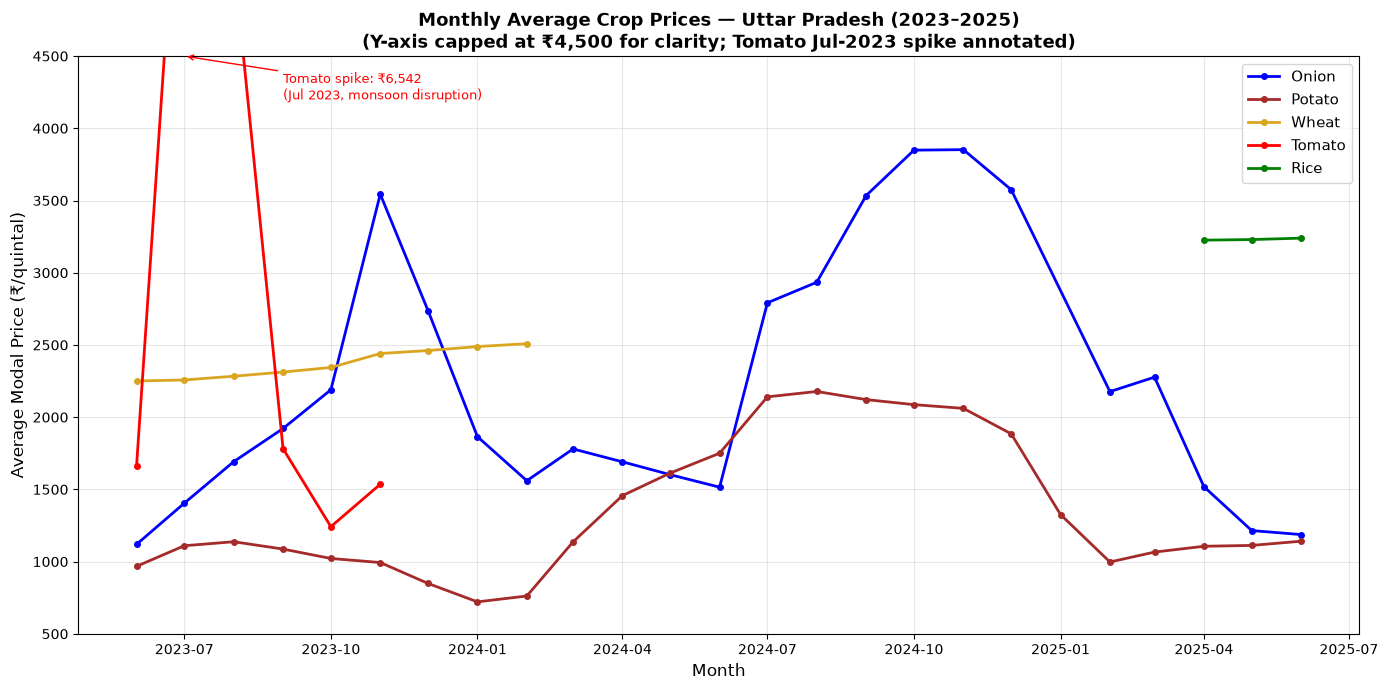

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

for crop, color in zip(crops, colors):
    crop_data = monthly_df[monthly_df['Commodity'] == crop].sort_values('Date')
    ax.plot(crop_data['Date'], crop_data['Avg_Modal_Price'],
            label=crop, color=color, linewidth=2, marker='o', markersize=4)

# Cap y-axis to make non-Tomato crops visible
ax.set_ylim(500, 4500)

# Annotate the Tomato spike that's now cut off
ax.annotate('Tomato spike: ₹6,542\n(Jul 2023, monsoon disruption)',
            xy=(pd.Timestamp('2023-07-01'), 4500),
            xytext=(pd.Timestamp('2023-09-01'), 4200),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Monthly Average Crop Prices — Uttar Pradesh (2023–2025)\n(Y-axis capped at ₹4,500 for clarity; Tomato Jul-2023 spike annotated)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

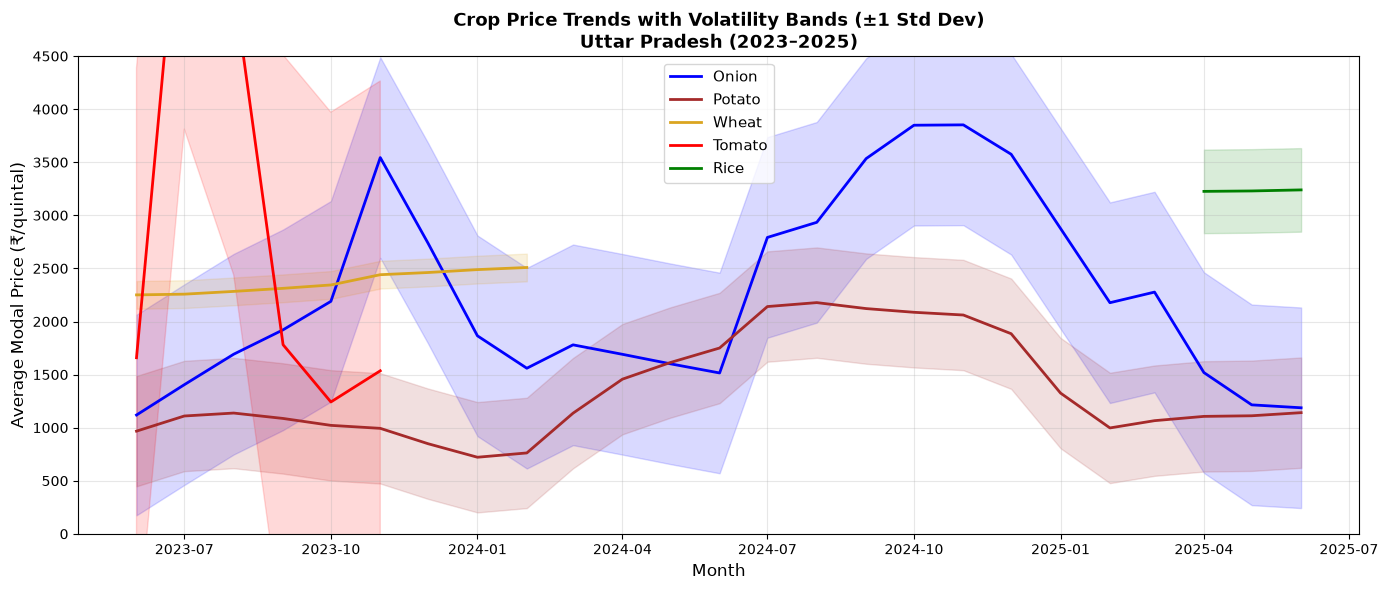

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

for crop, color in zip(crops, colors):
    crop_data = monthly_df[monthly_df['Commodity'] == crop].sort_values('Date')
    
    mean_price = crop_data['Avg_Modal_Price']
    
    # Get std for this crop from crop_summary
    std_val = crop_summary[
        crop_summary['Commodity'] == crop
    ]['Std_Price'].values[0]
    
    # Plot the mean line
    ax.plot(crop_data['Date'], mean_price,
            label=crop, color=color, linewidth=2)
    
    # Plot shaded uncertainty band (mean ± std)
    ax.fill_between(crop_data['Date'],
                    mean_price - std_val,
                    mean_price + std_val,
                    alpha=0.15, color=color)

ax.set_ylim(0, 4500)
ax.set_title('Crop Price Trends with Volatility Bands (±1 Std Dev)\nUttar Pradesh (2023–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

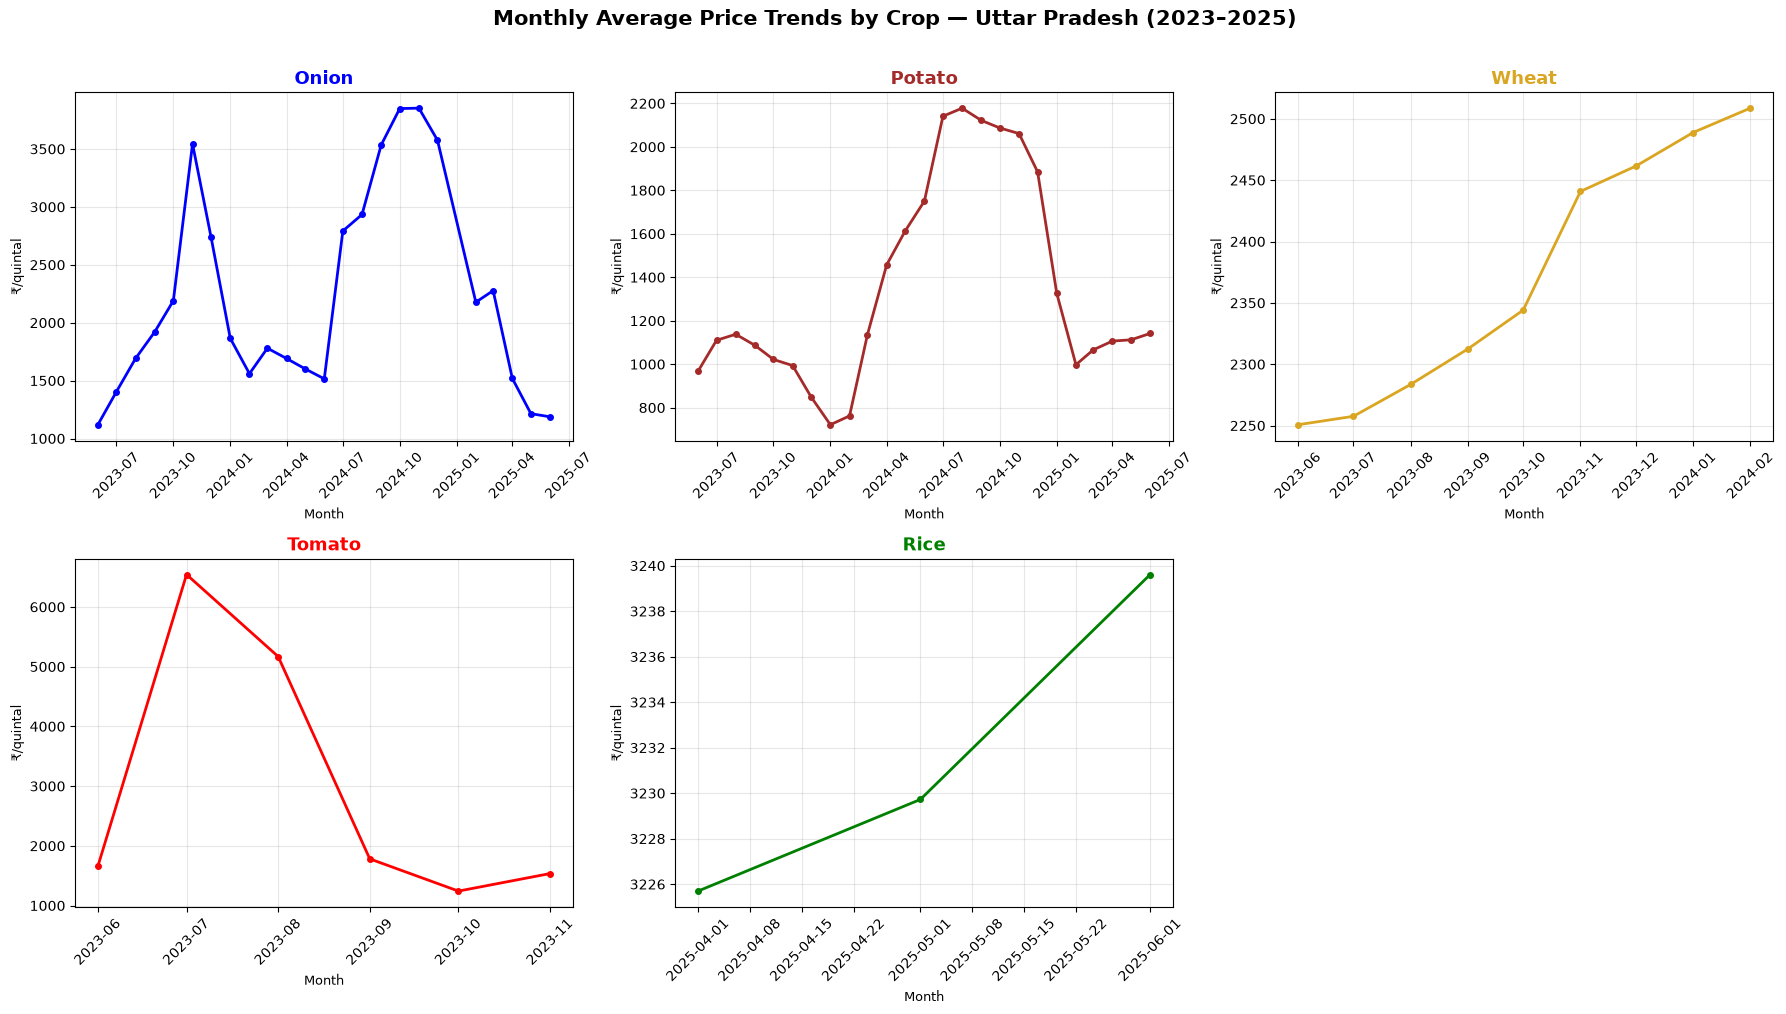

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for idx, (crop, color) in enumerate(zip(crops, colors)):
    ax = axes[idx]
    crop_data = monthly_df[
        monthly_df['Commodity'] == crop
    ].sort_values('Date')
    
    ax.plot(crop_data['Date'], crop_data['Avg_Modal_Price'],
            color=color, linewidth=2, marker='o', markersize=4)
    
    ax.set_title(f'{crop}', fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Month', fontsize=9)
    ax.set_ylabel('₹/quintal', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide the 6th empty subplot (2×3 grid = 6 panels, but we have 5 crops)
axes[5].set_visible(False)

fig.suptitle('Monthly Average Price Trends by Crop — Uttar Pradesh (2023–2025)',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

In [11]:
import os
os.makedirs("../plots", exist_ok=True)

In [12]:
plt.savefig("../plots/monthly_price_trends.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [13]:
plt.savefig("../plots/crop_comparison.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [14]:
plt.savefig("../plots/crop_subplots.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [15]:
import os
print(os.listdir("../plots"))

['crop_comparison.png', 'crop_subplots.png', 'monthly_price_trends.png']


## Day 5 Summary — Data Visualization & Price Trend Analysis

### Setup
Created notebook 04_visualization.ipynb. Reloaded clean_mandi_prices.csv 
and monthly_crop_prices.csv. Recreated Date column in monthly_df using 
Year+Month string concatenation + pd.to_datetime().

### Part 1 — Matplotlib fundamentals
- Figure = entire canvas; Axes = individual plot panel within the figure
- Used object-oriented style (fig, ax = plt.subplots()) throughout — 
  gives explicit control over each chart element
- Key parameters learned: figsize, marker, markersize, alpha, linewidth, 
  set_title, set_xlabel, set_ylabel, grid, tight_layout

### Part 2 & 3 — Individual crop trends and seasonality

**Onion:** Clear repeating seasonal pattern — low in June (₹1100-₹1500), 
peaks October-November (₹3500-₹3820), falls back. Pattern repeats 
consistently across both 2023 and 2024 — genuine seasonality. 2024 peak 
slightly higher than 2023 (upward trend overlaid on seasonal cycle).

**Tomato:** Sharp monsoon spike (Jun ₹1659 → Jul ₹6542 → crash). 
Single-year data (2023 only). Pattern is event-driven (supply shock), 
not gradual seasonality. Most volatile crop by far (CV=73%).

**Wheat:** Nearly flat line (₹2250-₹2510). Consistent upward drift 
confirming annual MSP increase. Least volatile crop (CV=5.55%). 
Auto-scaling trap: on its own subplot, the small drift looks dramatic 
but represents only ₹260 of actual movement.

**Potato:** Unexpected — flat in 2023 (₹700-₹1100), large spike 
mid-2024 (peaking ₹2150), back to flat in 2025. More likely a 
one-time market event than reliable seasonality. Lowest absolute 
prices of any crop.

**Rice:** 3 data points (Apr-Jun 2025 only). Flat ~₹3225-₹3240. 
Only ₹12 range — auto-scaling makes it look dramatic. 
Not suitable for trend/seasonality analysis.

### Part 4 — Combined crop comparison
- Y-axis capping (set_ylim) essential when one crop (Tomato) 
  dominates otherwise
- ax.annotate() used to acknowledge the cut-off spike honestly
- Key visual insight: Wheat is the stable baseline; Onion shows 
  the clearest multi-year seasonal pattern; crops have distinct 
  risk/return profiles visible at a glance

### Part 5 — Volatility bands
- fill_between() creates shaded ±1 std dev bands around mean lines
- Wheat band nearly invisible (std=₹131); Onion band spans ~₹1890; 
  Tomato band extends off the chart (std=₹2730)
- Bands visually communicate risk to non-technical users better 
  than a CV number alone

### Part 6 — Subplots
- plt.subplots(nrows=2, ncols=3) creates a grid; axes.flatten() 
  converts 2D array to 1D for easy looping
- Each crop gets auto-scaled y-axis — reveals individual structure 
  (Wheat's trend, Rice's flatness) but makes cross-crop comparison 
  misleading
- Key lesson: combined chart = use for comparison; 
  subplots = use for individual crop storytelling

### Key visualization lessons learned
1. Always check chart titles match the data being plotted
2. Auto-scaling can be misleading — a dramatic-looking line 
   might represent tiny actual variation (Rice: ₹12 range)
3. One outlier (Tomato spike) can compress all other data — 
   y-axis capping + annotation is the honest fix
4. Markers (marker='o') show actual data points vs interpolated lines
5. fill_between() communicates uncertainty visually — more intuitive 
   than a CV number for non-technical users

### Outputs saved
- plots/monthly_price_trends.png
- plots/crop_comparison.png  
- plots/crop_subplots.png